## Lab 1 Solution

Loading and preparing MNIST image data for a neural network pipeline in PyTorch (local version, no Colab).

The data is:
- Actively loaded;
- Augmented on-the-fly;
- Split into training / validation / test partitions;
- Normalized inside the dataloader.

### Static code 1

In [1]:
# @title Importing Necessary Packages

from torchvision.transforms import v2
import torchvision.datasets as datasets
import torch.utils.data as data
import copy

import matplotlib.pyplot as plt
import numpy as np
import random
import torch

import os
from pathlib import Path

from torch.utils.data import Dataset, DataLoader

# function to ensure reproducibility by fixing random state
def set_seed(seed_value):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1)

ModuleNotFoundError: No module named 'torchvision'

In [ ]:
# @title Save path

# Local directory containing the MNIST dataset (has MNIST/raw inside).
save_dir = r""C:\Users\DELL\Downloads\NN_task\mnist-data-4c714cfe-45a2-41ba-b6d7-961e5ad20d70\data"

### Task 1
#### Step 1: Define processing pipeline

`train_transforms` applies random rotation and random crop (augmentation) before
converting to a normalized float tensor. `test_transforms` only converts and normalizes.

In [ ]:
mnist_mean = 0.13066048920154572
mnist_std = 0.30810779333114624

train_transforms = v2.Compose([
    v2.RandomRotation(5, fill=0),
    v2.RandomCrop(28, padding=2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((mnist_mean,), (mnist_std,)),
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((mnist_mean,), (mnist_std,)),
])

#### Step 2: Load in the MNIST data and apply transforms

Load the train and test pools, then split the train pool 90/10 into train and
validation. `random_split` subsets share the same underlying dataset object, so the
validation split is deep-copied before its transform is overwritten with
`test_transforms` (validation data should not be augmented).

In [ ]:
train_data = datasets.MNIST(root=save_dir, train=True, download=True, transform=train_transforms)
test_data = datasets.MNIST(root=save_dir, train=False, download=True, transform=test_transforms)

split_ratio = 0.9
n_train = int(len(train_data) * split_ratio)
n_validate = len(train_data) - n_train

train_data, validate_data = data.random_split(train_data, [n_train, n_validate])

validate_data = copy.deepcopy(validate_data)
validate_data.dataset.transform = test_transforms

Check: the train split keeps the augmentation transforms; validation and test only convert and normalize.

In [ ]:
print("train transform:", train_data.dataset.transform);
print("valid transform:", validate_data.dataset.transform);
print("test transform:", test_data.transform)

train transform: Compose(
      RandomRotation(degrees=[-5.0, 5.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      RandomCrop(size=(28, 28), padding=[2, 2, 2, 2], pad_if_needed=False, fill=0, padding_mode=constant)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.13066048920154572], std=[0.30810779333114624], inplace=False)
)
valid transform: Compose(
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.13066048920154572], std=[0.30810779333114624], inplace=False)
)
test transform: Compose(
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.13066048920154572], std=[0.30810779333114624], inplace=False)
)


#### Step 3: Make data loaders

Batch size 50; shuffle only the training loader. `set_seed(1)` is called first so
results are reproducible.

In [ ]:
set_seed(1)
train_loader = DataLoader(train_data, batch_size=50, shuffle=True)
validate_loader = DataLoader(validate_data, batch_size=50, shuffle=False)
test_loader = DataLoader(test_data, batch_size=50, shuffle=False)

Check: pixel slices from the underlying (raw) data of each loader.

In [ ]:
print(test_loader.dataset.data[0][5:10, 5:10])
print(train_loader.dataset.dataset.data[0][5:10, 5:10])
print(validate_loader.dataset.dataset.data[0][5:10, 5:10])

tensor([[  0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0],
        [  0,  84, 185, 159, 151],
        [  0, 222, 254, 254, 254],
        [  0,  67, 114,  72, 114]], dtype=torch.uint8)
tensor([[  0,   0,   0,   0,   0],
        [  0,   0,   0,  30,  36],
        [  0,   0,  49, 238, 253],
        [  0,   0,  18, 219, 253],
        [  0,   0,   0,  80, 156]], dtype=torch.uint8)
tensor([[  0,   0,   0,   0,   0],
        [  0,   0,   0,  30,  36],
        [  0,   0,  49, 238, 253],
        [  0,   0,  18, 219, 253],
        [  0,   0,   0,  80, 156]], dtype=torch.uint8)


#### Step 4: Visualize one of the images

Pull one batch from the training loader and display the second image (`idx = 1`)
with its label as the title.

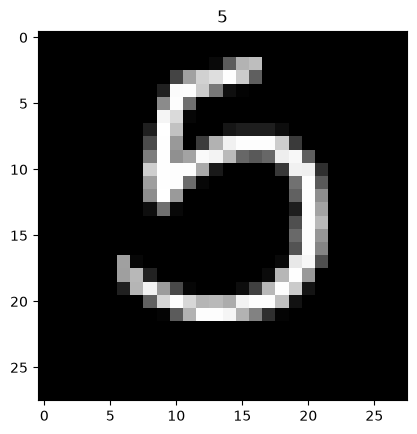

In [ ]:
images, labels = next(iter(train_loader))

idx = 1
image = images[idx].squeeze()
label = labels[idx].item()

plt.imshow(image, cmap="gray")
plt.title(label)
plt.show()